# PnPMass
*Notebook reproducing the results from Leterme, H. Leterme, A. Tersenov, J. Fadili, and J.-L. Starck, “A plug-and-play approach with fast uncertainty quantification for weak lensing mass mapping,” Oct. 2025.*

**Inverse problem:**
$$
\gamma = A\kappa + n,
$$
where:
- $\gamma$ noisy shear map (observation);
- $\kappa$ convergence map to recover;
- $A$ adjoint Kaiser-Squires operator (known) (may include a mask);
- $n \sim \mathcal N(0,\, \Sigma)$ with $\Sigma$ known diagonal covariance matrix (uncorrelated Gaussian noise).

**Plug-and-play FBS algorithm** with "noise-whitening" data-fidelity, defined as
$$
f_\gamma(\kappa') := \frac12 \|\gamma - A\kappa'\|_{\Sigma^{-1/2}}^2.
$$
**Forward step** with step size $\tau > 0$:
$$
\begin{align*}
\kappa_0^{(k+1)}
    &:= \kappa^{(k)} - \tau \nabla f_\gamma(\kappa^{(k)}) \\
    &= \kappa^{(k)} + \tau A^\top\Sigma^{-1/2}(\gamma - A\kappa^{(k)}).
\end{align*}
$$
**Backward step:**
$$
\kappa^{(k+1)} := F(\kappa_0^{(k+1)},\, \tau),
$$
where $F(\cdot,\, \tau)$ is a noise-level-aware denoiser (in this notebook, SUNet trained on simulated data).

**Hypothesis:** for $k$ large enough,
$$
\kappa_0^{(k)} \approx \kappa + n_0,
$$
with $n_0 \sim \mathcal N(0, \tau^2)$ (white Gaussian noise with standard deviation equal to the step size $\tau$).
Then, we get a point estimate:
$$
\hat\kappa := F(\kappa_0^{(k)}, \tau).
$$

PnPMass has been implemented using the DeepInverse library (`https://deepinv.github.io`), which is built upon PyTorch.

In [1]:
%config InlineBackend.figure_format = 'svg'
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
import os
import random
import tqdm
import numpy as np
import matplotlib.pyplot as plt
import torch
import deepinv as dinv

import wlmmuq as wl
import wlmmuq.data.kappatng as wlktng
import wlmmuq.data.torch as wlds
import wlmmuq.data.cosmos as wlcosmos
import wlmmuq.models.torch as wlnn
import wlmmuq.models.deepinv.iterativemm as wlpnp
import wlmmuq.utils as wlutils

/local/home/hl285110/Documents/Code/venv/wlmmuq/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/local/home/hl285110/Documents/Code/venv/wlmmuq/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. 

Configuration file found in /local/home/hl285110/.config/wlmmuq


/local/home/hl285110/Documents/Code/venv/wlmmuq/lib/python3.12/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [3]:
model_dir = wl.MODEL_DIR
path_to_test_dataset = wl.PATH_TO_TEST_DATASET
path_to_ps = wl.PATH_TO_PS
path_to_std_noise = wl.PATH_TO_STD_NOISE
path_to_mask = wl.PATH_TO_MASK
path_to_extent = wl.PATH_TO_EXTENT

In [4]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

In [29]:
nimgs_test = 512
batch_size = 32
imgsize = 384

# For imshow
imgsize_imshow = 304
vmin = -0.04
vmax = 0.29
vmax_gamma = 0.14
om = 1
idx = 0 # Index of the image to display

We check if CUDA is available and set the device accordingly. Note that running computations on CPU is significantly slower than on GPU. You may want to reduce the number of images (`nimgs_test`), or adjust the batch size (`batch_size`) in case of memory issues.

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cpu


## Load noise standard deviation and noise

Diagonal elements of $\Sigma$ and masked pixels.

The noise standard deviation has been obtained by binning the COSMOS shape galaxy catalog (https://www.aanda.org/articles/aa/abs/2010/08/aa13577-09/aa13577-09.html) at a resolution of $0.29$ arcmin per pixel, to match the $\kappa$-TNG dataset of simulated convergence maps (https://academic.oup.com/mnras/article/502/4/5593/6133466).

The noise standard deviation is given, for each pixel $k$, by 
\begin{equation}
    \sigma_k = \frac{\sigma_{\text{ell}}}{\sqrt{N_k}},
\end{equation}
where $\sigma_{\text{ell}}$ denotes the intrinsic shape dispersion of galaxies, and $N_k$ denotes the number of measured galaxies.

In [7]:
# cat_cosmos_bright, _ = wlcosmos.cosmos_catalog()
# cat_cosmos_bright = wlcosmos.filter_by_redshifts(cat_cosmos_bright, wlktng.MAX_Z)
# data_dict = wlktng.get_data_from_cosmos_ktng(cat_cosmos_bright, imgsize)

# extent = torch.tensor(data_dict["extent"]) # For imshow
# shapedisp = data_dict["shapedisp"] # Intrinsic shape dispersion
# ngal = data_dict["ngal"] # Number of galaxies per pixel
# mask = data_dict["mask"] # Mask

# std_noise = wlutils.get_std_noise(ngal, shapedisp, std_noise_mask=0) # Noise standard deviation

In [8]:
# Alternatively, load precomputed data (uncomment the following lines)
std_noise = torch.load(path_to_std_noise)
mask = torch.load(path_to_mask)
extent = torch.load(path_to_extent)

In [9]:
ra, dec = np.array(wlcosmos.COSMOS_VERTICES).T # Survey boundaries

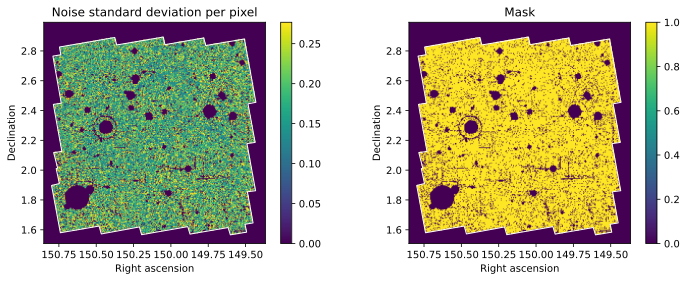

In [10]:
plt.figure(figsize=(12, 4))
plt.subplot(121)
wlutils.skyshow(
    std_noise, imgsize=imgsize_imshow,
    boundaries=(ra, dec), extent=extent
)
plt.title("Noise standard deviation per pixel")
plt.subplot(122)
wlutils.skyshow(
    mask, imgsize=imgsize_imshow,
    boundaries=(ra, dec), extent=extent
)
plt.title("Mask")
plt.show()

## Step size estimation

**Requirement for convergence:**
$$
\tau < 2 / \|A^\top \Sigma^{-1/2} A\|,
$$
where $\|\cdot\|$ denotes the spectral norm.

This upper bound can be estimated using the power iteration method.

In [11]:
# Define the forward model for the inverse problem, with noise
physics = wlpnp.MassMapping(sigma=std_noise, mask=mask).to(device)

# Define a multicplicative factor to avoid the upper bound itself (strict inequality)
eps = 1e-9

In [12]:
# Estimate the upper bound using the power iteration method
sup_step_size = wlutils.get_sup_step_size(
    param_mahalanobis=std_noise, # Diagonal elements of $\Sigma^{1/2}$
    physics=physics, # Contains the forward operator $A$ and its adjoint
    device=device
)
step_size = sup_step_size * (1 - eps)
print(f"Upper bound step size = {sup_step_size:.2e}")
print(f"Selected step size = {step_size:.2e}")

/local/home/hl285110/Documents/Code/venv/wlmmuq/lib/python3.12/site-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4322.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Upper bound step size = 1.76e-01
Selected step size = 1.76e-01


**Remark:**

A more naive method to estimate the step size is to consider the following property of the spectral norm:
$$
\begin{align*}
\|A^\top \Sigma^{-1/2} A\|
    &\leq \|A\|^2 \, \|\Sigma^{-1/2}\| \\
    &= \|\Sigma^{-1/2}\|.
\end{align*}
$$
Therefore, a smaller upper bound for the step size can be obtained:
$$
\tau < 2\sigma_{\min},
$$
where $\sigma_{\min}$ denotes the smallest noise standard deviation in $\Sigma$ (pixels having the largest number of observed galaxies).

In [13]:
naive_step_size = 2 * std_noise[mask].min() # The noise standard deviation is undefined in the mask
naive_step_size *= (1 - eps)
print(f"Naive step size = {naive_step_size:.2e}")

Naive step size = 1.48e-01


However, as we will see, the PnPMass algorithm produces more accurate results if $\tau$ is larger. Therefore, the first method is recommended for choosing the step size.

## Results training denoiser

| Property | Value |
|----------|----------|
| Model | SUNet (noise-aware version) |
| Nb parameters | $7\,251\,671$ |
| Batch size | $16$ |
| Initial learning rate | $10^{-3}$ |
| Nb epochs | $100$ |
| Training loss | MSE ($\ell^2$-loss) |
| Size training set | $70\,560$ |
| Image size | $384 \times 384$ |
| Resolution | $0.29$ arcmin per pixel |
| Range for noise level | $0.0 < \sigma < 0.2$ |

The training set has been obtained by randomly rotating and cropping mock $\kappa$-maps from the $\kappa$-TNG dataset. Redshifts above $z = 2.6$ have been discarded to match the COSMOS S10 galaxy shape catalog. For each input image, a white Gaussian noise with standard deviation randomly picked between $0.0$ and $0.2$ has been generated.

**Note:**

A mean-centering layer has been added at the output of the network. This is because convergence maps can only be estimated up to an additive constant (mass-sheet degeneracy). In practice, we only consider variations around the mean value. Additionally, this projection ensures convergence of the PnPMass algorithm to a unique fixed point (under a few additional assumptions).

### Load trained model

In [14]:
dirname_denoiser = (
    "denoiser_arch_SUNetNoiseAware_scale_0.2_scale-min_01.0_batch-size_16_"
    "nepochs_100_learning-rate_1e-3"
)
timestamp_denoiser = "20250613_143319"
filename_denoiser = os.path.join(model_dir, dirname_denoiser, "pe", timestamp_denoiser, "ckp_100.pth.tar")
checkpoint_denoiser = torch.load(filename_denoiser, map_location="cpu")

In [15]:
model = wlnn.SUNetNoiseAware(map_size=imgsize)
model.load_state_dict(checkpoint_denoiser["state_dict"])
model.to(device).eval()
model.summary()

Layer (type:depth-idx)                             Output Shape              Param #
SUNetNoiseAware                                    [1, 1, 384, 384]          1
├─Conv2d: 1-1                                      [1, 48, 384, 384]         912
├─PatchEmbed: 1-2                                  [1, 9216, 48]             --
│    └─Conv2d: 2-1                                 [1, 48, 96, 96]           36,912
│    └─LayerNorm: 2-2                              [1, 9216, 48]             96
├─Dropout: 1-3                                     [1, 9216, 48]             --
├─ModuleList: 1-4                                  --                        --
│    └─BasicLayer: 2-3                             [1, 2304, 96]             --
│    │    └─ModuleList: 3-1                        --                        58,480
│    │    └─PatchMerging: 3-2                      [1, 2304, 96]             18,816
│    └─BasicLayer: 2-4                             [1, 576, 192]             --
│    │    └─ModuleList:

### Test the network on a simple denoising task

Instantiate the data loader

In [16]:
test_dataloader_denoiser = wlds.HDF5DatasetDenoiser(
    hdf5_filepath=path_to_test_dataset,
    nimgs=nimgs_test, batch_size=batch_size,
    output_shape=imgsize,
    scale=step_size, shuffle=False, newaxis=True
).to_dataloader()

/local/home/hl285110/Documents/Code/weaklensing/wlmmuq/data/base_dataset.py:293: UserWarning: The 'filename_ori' dataset is missing; input images will not be sorted or filtered by filename.
  warnings.warn(


Define RMSE metrics, restricted to the pixels outside the mask

In [17]:
rmse = wlpnp.RMSE(mask=mask, meancentering=True).to(device)

Apply denoising by batch and compute RMSE

In [18]:
tmp_kappa_true = []
tmp_kappa_noisy = []
tmp_kappa_denoised = []
tmp_rmse_denoised = []
tmp_l2norm = []
for kappa_true, kappa_noisy in tqdm.tqdm(test_dataloader_denoiser):

    kappa_true = kappa_true.to(device)
    kappa_noisy = kappa_noisy.to(device)
    with torch.no_grad():
        kappa_denoised = model(kappa_noisy, sigma=step_size)
        rmse_denoised = rmse(kappa_denoised, kappa_true)
        l2norm = rmse(kappa_true, 0)
    
    tmp_kappa_true.append(kappa_true)
    tmp_kappa_noisy.append(kappa_noisy)
    tmp_kappa_denoised.append(kappa_denoised)
    tmp_rmse_denoised.append(rmse_denoised)
    tmp_l2norm.append(l2norm)

kappa_true = torch.cat(tmp_kappa_true, dim=0)
kappa_noisy = torch.cat(tmp_kappa_noisy, dim=0)
kappa_denoised = torch.cat(tmp_kappa_denoised, dim=0)
rmse_denoised = torch.cat(tmp_rmse_denoised, dim=0)
l2norm = torch.cat(tmp_l2norm, dim=0)

100%|██████████| 2/2 [00:09<00:00,  4.97s/it]


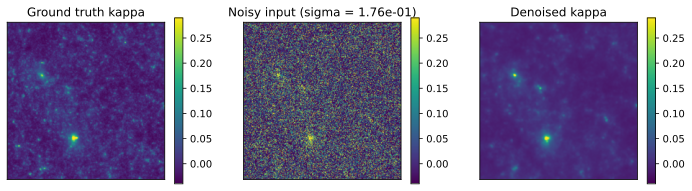

In [19]:
plt.figure(figsize=(12, 3))
plt.subplot(131)
wlutils.skyshow(
    kappa_true[idx, 0].cpu(),
    title="Ground truth kappa",
    vmin=vmin, vmax=vmax, extent=extent,
    printxylabels=False,
    printxticks=False, printyticks=False, printcolorbar=True,
    imgsize=imgsize_imshow
)
plt.subplot(132)
wlutils.skyshow(
    kappa_noisy[idx, 0].cpu(),
    title=f"Noisy input (sigma = {step_size:.2e})",
    vmin=vmin, vmax=vmax, extent=extent,
    printxylabels=False,
    printxticks=False, printyticks=False, printcolorbar=True,
    imgsize=imgsize_imshow
)
plt.subplot(133)
wlutils.skyshow(
    kappa_denoised[idx, 0].cpu(),
    title="Denoised kappa",
    vmin=vmin, vmax=vmax, extent=extent,
    printxylabels=False,
    printxticks=False, printyticks=False, printcolorbar=True,
    imgsize=imgsize_imshow
)
plt.show()

In [20]:
nrmse_denoised = rmse_denoised / l2norm
print(
    f"Mean NRMSE across {nimgs_test} images = "
    f"{10**om * nrmse_denoised.mean(dim=0).item():.2f}e-{om} +/- "
    f"{10**om * nrmse_denoised.std(dim=0).item():.2f}e-{om}"
)

Mean NRMSE across 2 images = 7.52e-1 +/- 0.72e-1


## PnPMass

In [30]:
niter = 8

### Load data

In [22]:
test_dataloader_massmapping = wlds.HDF5DatasetMassMapping(
    hdf5_filepath=path_to_test_dataset,
    nimgs=nimgs_test, batch_size=batch_size,
    output_shape=imgsize,
    std_noise=std_noise.cpu(), mask=mask.cpu(),
    shuffle=False, newaxis=True
).to_dataloader()

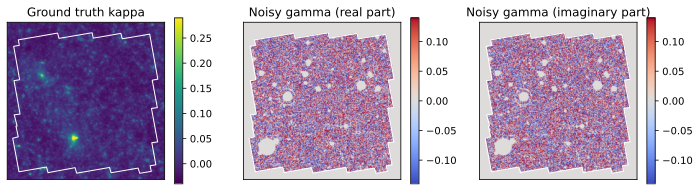

In [23]:
kappa_true, gamma_noisy = next(iter(test_dataloader_massmapping))

plt.figure(figsize=(12, 3))
plt.subplot(131)
wlutils.skyshow(
    kappa_true[idx, 0],
    title="Ground truth kappa",
    vmin=vmin, vmax=vmax, extent=extent,
    boundaries=(ra, dec), printxylabels=False,
    printxticks=False, printyticks=False, printcolorbar=True,
    imgsize=imgsize_imshow
)
plt.subplot(132)
wlutils.skyshow(
    gamma_noisy.real[idx, 0],
    title="Noisy gamma (real part)",
    cmap="coolwarm", vmin=-vmax_gamma, vmax=vmax_gamma,
    extent=extent, boundaries=(ra, dec), printxylabels=False,
    printxticks=False, printyticks=False, printcolorbar=True,
    imgsize=imgsize_imshow
)
plt.subplot(133)
wlutils.skyshow(
    gamma_noisy.imag[idx, 0],
    title="Noisy gamma (imaginary part)",
    cmap="coolwarm", vmin=-vmax_gamma, vmax=vmax_gamma,
    extent=extent, boundaries=(ra, dec), printxylabels=False,
    printxticks=False, printyticks=False, printcolorbar=True,
    imgsize=imgsize_imshow
)
plt.show()

### Instantiate PnPMass models

First, we load the PyTorch modules corresponding to:
- the data fidelity for the forward step (implementing a `.grad` method);
- the "prior" for the backward step (implementing a `.prox` method, i.e., the trained denoiser in a PnP context).

In [24]:
data_fidelity = (
    wlpnp.Mahalanobis(param_vector=std_noise)
) # `param_vector` contains the diagonal elements of $\Sigma^{1/2}$ (noise-whitening data fidelity)
prior = dinv.optim.prior.PnP(model) # Denoiser

We now consider three settings, with three different step sizes.

In the sets of parameters below, the step size is used for both the forward step (`"stepsize"`) and the backward step (`"g_param"`), as explained in the introduction of this notebook.

In [25]:
listof_step_size = [alpha * step_size for alpha in (0.5, 0.75, 1.)]
listof_params_algo = [
    {"stepsize": tau, "g_param": tau} for tau in listof_step_size
]

The PnP models below are instance of `deepinv.optim.BaseOptim` (inheriting from `torch.nn.Module`).

In [26]:
listof_pnpmass_model = [
    wlpnp.optim_builder(
        iteration="PGD", params_algo=params_algo,
        data_fidelity=data_fidelity, prior=prior,
        early_stop=False, max_iter=niter, custom_init=wlpnp.zero_init,
        metric_dict={"rmse": rmse}, verbose=True
    ).to(device) \
        for params_algo in listof_params_algo
]

### Run PnPMass by batch, for various step sizes

The ground truth is passed as argument of the `forward` method (`x_gt=kappa_True`), for monitoring purpose (`compute_metrics=True`).

**Note:** For convenience, PnPMass can also be executed from the following bash script:
```bash
python scripts/pnpmass.py -c denoiser_arch_SUNetNoiseAware_scale_0.2_scale-min_0.0_batch-size_16_nepochs_100_learning-rate_1e-3 -a torch.SUNetNoiseAware -t 20250613_143319 -alph 0.5 0.75 1.0 -i 8 -w 8 -o results_pnpmass_niter_8 --save-tensors --nimgs-save 8 --seed 42 -v
```
The results are then saved in dedicated files, one for each step size.

In [ ]:
# filename_results = f"results_pnpmass_niter_{niter}"
# timestamp_results = "20250916_131846"

In [ ]:
listof_kappa_pnpmass = []
listof_nrmse_pnpmass = []
for tau, pnpmass in zip(listof_step_size, listof_pnpmass_model):

    # Run PnPMass in this notebook
    tmp_kappa_true = []
    tmp_kappa_pnpmass = []
    tmp_nrmse_pnpmass = []

    pbar = tqdm.tqdm(test_dataloader_massmapping)
    pbar.set_description(f"Step size = {tau:.3f}")
    for kappa_true, gamma_noisy in pbar:

        kappa_true = kappa_true.to(device)
        gamma_noisy = gamma_noisy.to(device)
        with torch.no_grad():
            kappa_pnpmass, metrics = pnpmass(
                gamma_noisy, physics, x_gt=kappa_true, compute_metrics=True
            )
            l2norm = rmse(kappa_true, 0) # Shape = (batch_size,)
        
        tmp_kappa_true.append(kappa_true)
        tmp_kappa_pnpmass.append(kappa_pnpmass)
        tmp_nrmse_pnpmass.append(metrics["rmse"] / l2norm) # Shape = (batch_size, niter)

    kappa_true = torch.cat(tmp_kappa_true, dim=0)
    kappa_pnpmass = torch.cat(tmp_kappa_pnpmass, dim=0) # Shape = (nimgs_test, 1, imgsize, imgsize)
    nrmse_pnpmass = torch.cat(tmp_nrmse_pnpmass, dim=0) # Shape = (nimgs_test, niter)

    # Alternatively, load results saved when running the Python script (uncomment the following lines)
    # filename_results_completed = (
    #     f"{filename_results}_step-size_{tau:.3f}_{timestamp_results}.pt"
    # )
    # filename_results_completed = os.path.join(
    #     model_dir, dirname_denoiser, "results_pnpmass", filename_results_completed
    # )
    # results_pnpmass = torch.load(filename_results_completed)
    # kappa_true = results_pnpmass["kappa_true"]
    # kappa_pnpmass = results_pnpmass["kappa_pred"]
    # nrmse_pnpmass = results_pnpmass["rmse"] / results_pnpmass["l2norm"] # Shape = (nimgs_test, niter)

    print(
        f"Mean NRMSE at iteration {niter} across {nimgs_test} images = "
        f"{10**om * nrmse_pnpmass.mean(dim=0)[-1].item():.2f}e-{om} +/- "
        f"{10**om * nrmse_pnpmass.std(dim=0)[-1].item():.2f}e-{om}"
    )
    listof_kappa_pnpmass.append(kappa_pnpmass)
    listof_nrmse_pnpmass.append(nrmse_pnpmass)

KeyError: 'kappa_true'

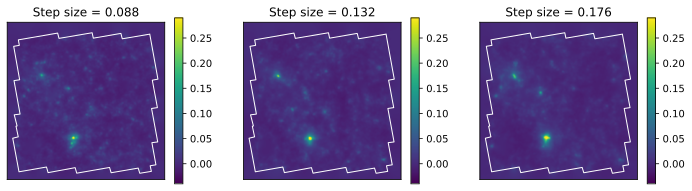

In [ ]:
plt.figure(figsize=(12, 3))
for i, (tau, kappa_pnpmass) in enumerate(zip(
    listof_step_size, listof_kappa_pnpmass
)):
    plt.subplot(1, 3, i + 1)
    wlutils.skyshow(
        kappa_pnpmass[idx, 0].cpu(),
        title=f"Step size = {tau:.3f}",
        vmin=vmin, vmax=vmax, extent=extent,
        boundaries=(ra, dec), printxylabels=False,
        printxticks=False, printyticks=False, printcolorbar=True,
        imgsize=imgsize_imshow
    )
plt.show()

We notice that smaller step sizes tend to produce hallucinations and degrade accuracy. Therefore, it is recommended to choose a step size close to the upper limit.

## PnPMass on non-Gaussian residuals

The above results can be improved by considering a priori knowledge about the underlying physics and the data structure. Convergence maps can be seen as the superposition of a Gaussian field and a non-Gaussian field:
$$
\kappa = \kappa_{\text{g}} + \kappa_{\text{ng}}.
$$
The Gaussian component, $\kappa_{\text{g}}$, can be estimated from the noisy shear map $\gamma$ using an iterative Wiener filter, assuming the power spectrum is known. Then, the inverse problem can be re-written as follows:
$$
\gamma_{\text{ng}} = A \kappa_{\text{ng}} + n,
$$
where $\gamma_{\text{ng}}$ denotes the residual shear map, satisfying:
$$
\gamma_{\text{ng}} := \gamma - A \kappa_{\text{g}}.
$$
Then, the PnPMass algorithm can be applied to estimate $\kappa_{\text{ng}}$. To this end, the denoiser must be trained on a simulated dataset where the Gaussian component has been subtracted from the ground truth. In practice, we have applied a Wiener filter to each noisy input.

### Load model trained on residuals

In [ ]:
dirname_denoiser_ng = (
    "denoiser_arch_SUNetNoiseAware_nongaussian_scale_0.2_scale-min_0.0_"
    "batch-size_16_nepochs_100_learning-rate_1e-3"
)
timestamp_denoiser_ng = "20250716_170944"
filename_denoiser_ng = os.path.join(model_dir, dirname_denoiser_ng, "pe", timestamp_denoiser_ng, "ckp_100.pth.tar")
checkpoint_denoiser_ng = torch.load(filename_denoiser_ng, map_location="cpu")

In [ ]:
model_ng = wlnn.SUNetNoiseAware(map_size=imgsize)
model_ng.load_state_dict(checkpoint_denoiser_ng["state_dict"])
model_ng.to(device).eval()
model_ng.summary()

Layer (type:depth-idx)                             Output Shape              Param #
SUNetNoiseAware                                    [1, 1, 384, 384]          1
├─Conv2d: 1-1                                      [1, 48, 384, 384]         912
├─PatchEmbed: 1-2                                  [1, 9216, 48]             --
│    └─Conv2d: 2-1                                 [1, 48, 96, 96]           36,912
│    └─LayerNorm: 2-2                              [1, 9216, 48]             96
├─Dropout: 1-3                                     [1, 9216, 48]             --
├─ModuleList: 1-4                                  --                        --
│    └─BasicLayer: 2-3                             [1, 2304, 96]             --
│    │    └─ModuleList: 3-1                        --                        58,480
│    │    └─PatchMerging: 3-2                      [1, 2304, 96]             18,816
│    └─BasicLayer: 2-4                             [1, 576, 192]             --
│    │    └─ModuleList:

### Get the Gaussian component extractor

The goal is to minimize the following objective, corresponding to the maximum a posteriori (MAP) estimate:
$$
\min_{\kappa'} f^{\mathcal L}_\gamma(\kappa') + g(\kappa'),
$$
where
$$
f^{\mathcal L}_\gamma(\kappa') := \frac12 \|\gamma - A\kappa'\|_{\Sigma^{-1}}^2
$$
denotes the negative log-likelihood (data fidelity), and
$$
g(\kappa') := \frac12 \|\kappa'\|_{\Omega^{-1}}^2
$$
denotes the Gaussian prior, with $\Omega := F^\ast P F$ encoding the power spectrum. 

**Iterative Wiener filtering:** forward-backward splitting (FBS) algorithm. Each iteration is defined by
$$
\kappa^{(k+1)} := \text{prox}_{\mu g}\left(
    \kappa^{(k)} - \mu \nabla f^{\mathcal L}_\gamma(\kappa^{(k)})
\right),
$$
where the step size $\mu$ satisfies:
$$
\mu < 2 / \|A^\top \Sigma^{-1} A\|.
$$

In [ ]:
niter_wiener = 12

The power spectrum has been computed on the $\kappa$-TNG training set, averaged over $2\,048$ simulated convergence maps.

In [ ]:
powerspectrum = torch.load(path_to_ps)

Compute the step size for the iterative Wiener algorithm, using the power iteration method. It is different from the one used for PnPMass, because the data fidelity term is not the same.

In [ ]:
step_size_wiener = wlutils.get_sup_step_size(
    param_mahalanobis=std_noise**2, # Diagonal elements of $\Sigma$, vs $\Sigma^{1/2}$ for PnPMass
    physics=physics, device=device
)
step_size_wiener *= (1 - eps)
print(f"Step size for the Gaussian extractor = {step_size_wiener:.2e}")

Step size for the Gaussian extractor = 1.47e-02


Instantiate the data fidelity and the prior for the iterative Wiener algorithm:

In [ ]:
data_fidelity_wiener = wlpnp.Mahalanobis(param_vector=std_noise**2) # Negative log-likelihood
prior_wiener = dinv.optim.PnP(
    wlpnp.ProximalWiener(powerspectrum)
) # Gaussian prior, defines the proximal operator
params_algo_wiener = {"stepsize": step_size_wiener, "g_param": step_size_wiener}

Instantiate the Wiener filter:

In [ ]:
wiener = wlpnp.optim_builder(
    iteration="PGD",
    params_algo=params_algo_wiener,
    data_fidelity=data_fidelity_wiener, prior=prior_wiener,
    early_stop=False, max_iter=niter_wiener, custom_init=wlpnp.zero_init,
).to(device)

### Instantiate the PnPMass model

In [ ]:
prior_ng = dinv.optim.prior.PnP(model_ng) # Denoiser trained on residulals

In [ ]:
listof_pnpmass_model_ng = [
    wlpnp.optim_builder(
        iteration="PGD", params_algo=params_algo,
        data_fidelity=data_fidelity, prior=prior_ng,
        early_stop=False, max_iter=niter, custom_init=wlpnp.zero_init,
        metric_dict={"rmse": rmse}, verbose=True
    ).to(device) \
        for params_algo in listof_params_algo
]

### Run PnPMass (residual version)

**Note:** As above, PnPMass can also be executed from the following bash script:
```bash
python scripts/pnpmass.py -c denoiser_arch_SUNetNoiseAware_nongaussian_scale_0.2_scale-min_0.0_batch-size_16_nepochs_100_learning-rate_1e-3 -a torch.SUNetNoiseAware -t 20250716_170944 --mode residual -alph 0.5 0.75 1.0 -i 8 -w 8 -o results_pnpmass_mode_residual_niter_8 --save-tensors --nimgs-save 8 --seed 42 -v
```

In [ ]:
# filename_results_res = f"results_pnpmass_mode_residual_niter_{niter}"
# timestamp_results_res = "20250916_131855"

In [ ]:
listof_kappa_pnpmass_res = []
listof_nrmse_pnpmass_res = []
for tau, pnpmass_ng in zip(listof_step_size, listof_pnpmass_model_ng):

    # Run PnPMass in this notebook
    tmp_kappa_true = []
    tmp_kappa_pnpmass_res = []
    tmp_nrmse_pnpmass_res = []

    pbar = tqdm.tqdm(test_dataloader_massmapping)
    pbar.set_description(f"Step size = {tau:.3f}")
    for kappa_true, gamma_noisy in pbar:

        kappa_true = kappa_true.to(device)
        gamma_noisy = gamma_noisy.to(device)
        with torch.no_grad():
            # Compute the Gaussian component using Wiener filtering
            kappa_g = wiener(
                gamma_noisy, physics, x_gt=None, compute_metrics=False
            )

            # Compute residuals
            gamma_noisy_ng = gamma_noisy - physics.A(kappa_g)
            kappa_true_ng = kappa_true - kappa_g

            # Run PnPMass on the residuals
            kappa_pnpmass_ng, metrics_res = pnpmass_ng(
                gamma_noisy_ng, physics, x_gt=kappa_true_ng, compute_metrics=True
            )
            l2norm = rmse(kappa_true, 0)

            # Add back the Gaussian component
            kappa_pnpmass_res = kappa_pnpmass_ng + kappa_g

        tmp_kappa_true.append(kappa_true)
        tmp_kappa_pnpmass_res.append(kappa_pnpmass_res)
        tmp_nrmse_pnpmass_res.append(metrics_res["rmse"] / l2norm)

    kappa_true = torch.cat(tmp_kappa_true, dim=0)
    kappa_pnpmass_res = torch.cat(tmp_kappa_pnpmass_res, dim=0) # Shape = (nimgs_test, 1, imgsize, imgsize)
    nrmse_pnpmass_res = torch.cat(tmp_nrmse_pnpmass_res, dim=0) # Shape = (nimgs_test, niter)

    # Alternatively, load results saved when running the Python script (uncomment the following lines)
    # filename_results_res_completed = (
    #     f"{filename_results_res}_step-size_{tau:.3f}_{timestamp_results_res}.pt"
    # )
    # filename_results_res_completed = os.path.join(
    #     model_dir, dirname_denoiser_ng, "results_pnpmass", filename_results_res_completed
    # )
    # results_pnpmass_res = torch.load(filename_results_res_completed)
    # kappa_true = results_pnpmass_res["kappa_true"]
    # kappa_pnpmass_res = results_pnpmass_res["kappa_pred"]
    # nrmse_pnpmass_res = results_pnpmass_res["rmse"] / results_pnpmass_res["l2norm"] # Shape = (nimgs_test, niter)

    print(
        f"Mean NRMSE at iteration {niter} across {nimgs_test} images = "
        f"{10**om * nrmse_pnpmass_res.mean(dim=0)[-1].item():.2f}e-{om} +/- "
        f"{10**om * nrmse_pnpmass_res.std(dim=0)[-1].item():.2f}e-{om}"
    )
    listof_kappa_pnpmass_res.append(kappa_pnpmass_res)
    listof_nrmse_pnpmass_res.append(nrmse_pnpmass_res)

Step size = 0.088: 100%|██████████| 2/2 [00:20<00:00, 10.42s/it]


Mean NRMSE at iteration 2 across 2 images = 7.89e-1 +/- 0.60e-1


Step size = 0.132: 100%|██████████| 2/2 [00:20<00:00, 10.15s/it]


Mean NRMSE at iteration 2 across 2 images = 7.70e-1 +/- 0.67e-1


Step size = 0.176: 100%|██████████| 2/2 [00:20<00:00, 10.15s/it]

Mean NRMSE at iteration 2 across 2 images = 7.66e-1 +/- 0.78e-1


Plot results for `step_size = 0.176`:

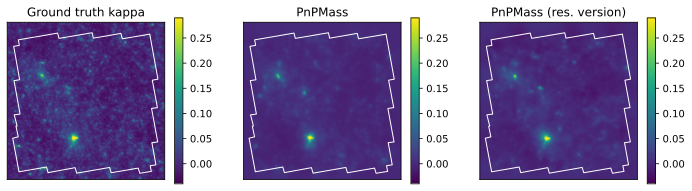

In [ ]:
plt.figure(figsize=(12, 3))

plt.subplot(131)
wlutils.skyshow(
    kappa_true[idx, 0].cpu(),
    title="Ground truth kappa",
    vmin=vmin, vmax=vmax, extent=extent,
    boundaries=(ra, dec), printxylabels=False,
    printxticks=False, printyticks=False, printcolorbar=True,
    imgsize=imgsize_imshow
)
plt.subplot(132)
wlutils.skyshow(
    listof_kappa_pnpmass[-1][idx, 0].cpu(),
    title="PnPMass",
    vmin=vmin, vmax=vmax, extent=extent,
    boundaries=(ra, dec), printxylabels=False,
    printxticks=False, printyticks=False, printcolorbar=True,
    imgsize=imgsize_imshow
)
plt.subplot(133)
wlutils.skyshow(
    listof_kappa_pnpmass_res[-1][idx, 0].cpu(),
    title="PnPMass (res. version)",
    vmin=vmin, vmax=vmax, extent=extent,
    boundaries=(ra, dec), printxylabels=False,
    printxticks=False, printyticks=False, printcolorbar=True,
    imgsize=imgsize_imshow
)
plt.show()

### Plot RMSE along PnP iterations

In [ ]:
iterations = np.arange(niter + 1)

In [ ]:
listof_configname = [
    "PnPMass",
    "PnPMass (res.)",
]
listof_nrmse = [
    listof_nrmse_pnpmass,
    listof_nrmse_pnpmass_res,
]

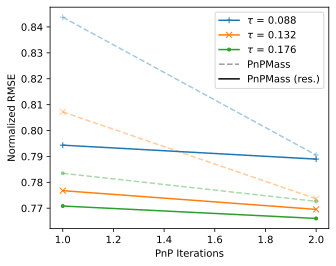

In [ ]:
listof_linestyle = ["--", "-", "-."]
listof_alpha = [0.4, 1.0, 0.2]

listof_marker = ["+", "x", "."]

isup = 2
plt.figure(figsize=(5, 4))
ax = plt.gca()
handles = []
for i, (configname, linestyle, alpha) in enumerate(zip(
    listof_configname, listof_linestyle, listof_alpha
)):
    ax.set_prop_cycle(None) # Reset colors
    for j, (nrmse_iterations, step_size, marker) in enumerate(zip(
        listof_nrmse[i], listof_step_size, listof_marker
    )):
        if i < isup:
            mean_rmse_iterations = nrmse_iterations.mean(dim=0)
            std_rmse_iterations = nrmse_iterations.std(dim=0)
            handle, = plt.plot(
                iterations[1:], mean_rmse_iterations[1:], linestyle=linestyle, alpha=alpha,
                marker=marker, label=r"$\tau$ = " + f"{step_size:.3f}"
            )
            if i == 1:
                handles.append(handle) # For the legend
    
# For the legend only
for i, (configname, linestyle, alpha) in enumerate(zip(
    listof_configname, listof_linestyle, listof_alpha
)):
    if i < isup:
        handle, = plt.plot(
            [], [], linestyle=linestyle, alpha=alpha, color='k', label=configname
        )
        handles.append(handle)
    
# plt.ylim(bottom=0.0175, top=0.0191)
plt.xlabel("PnP Iterations")
plt.ylabel("Normalized RMSE")
plt.legend(handles=handles)
plt.show()